In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Configurar el estilo oscuro de las gráficas
plt.style.use('dark_background')
sns.set_theme(style="darkgrid")

# Configuración adicional para un tema más oscuro
plt.rcParams['figure.facecolor'] = '#1a1a1a'
plt.rcParams['axes.facecolor'] = '#2b2b2b'
plt.rcParams['axes.edgecolor'] = '#444444'
plt.rcParams['text.color'] = '#ffffff'
plt.rcParams['axes.labelcolor'] = '#ffffff'
plt.rcParams['xtick.color'] = '#ffffff'
plt.rcParams['ytick.color'] = '#ffffff'

In [7]:
df = pd.read_csv(r'./data/dataset_covid.csv')
df.head()

,coordenada,covid
0,0.710379,1
1,0.968178,1
2,0.859276,1
3,0.569438,1
4,0.532627,1


In [8]:
reds = df['coordenada'][df['covid'] == 1].values
blues = df['coordenada'][df['covid'] == 0].values

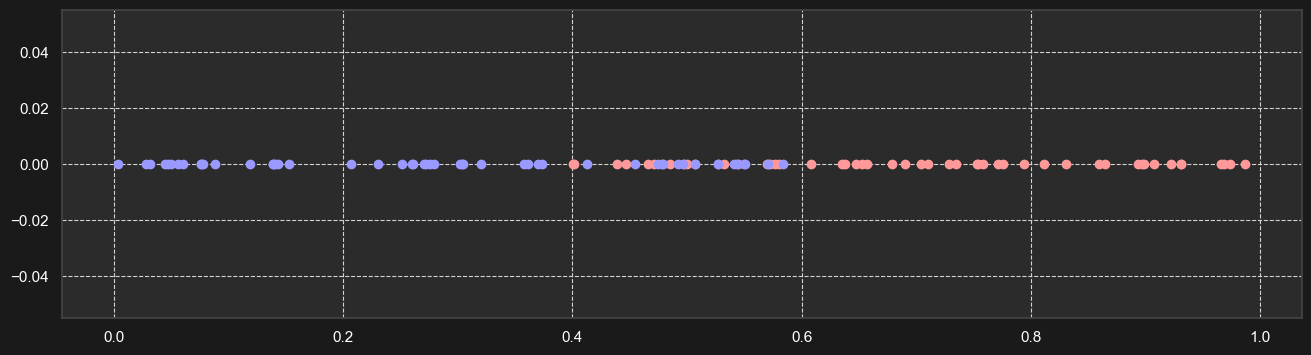

In [ ]:
fig, ax = plt.subplots(figsize=(16, 4))

# Usar tonos pastel para los puntos
plt.scatter(reds, np.zeros(reds.shape), color='#ff9999')
plt.scatter(blues, np.zeros(blues.shape), color='#9999ff')
plt.grid(color='lightgray', linewidth=0.8, linestyle='--')
plt.show()

In [ ]:
from numpy.typing import ArrayLike

def true_positive_rate_off(real: ArrayLike, pred: ArrayLike):
    M = real * pred
    return np.sum(M)


def true_negative_rate_off(real: ArrayLike, pred: ArrayLike):
    M = (1 - real) * (1 - pred)
    return np.sum(M)


def false_positive_rate_off(real: ArrayLike, pred: ArrayLike):
    neg = np.sum(1 - real)
    tnn = true_negative_rate_off(real, pred)
    return neg - tnn


def false_negative_rate_off(real: ArrayLike, pred: ArrayLike):
    pos = np.sum(real)
    tpp = true_positive_rate_off(real, pred)
    return pos - tpp

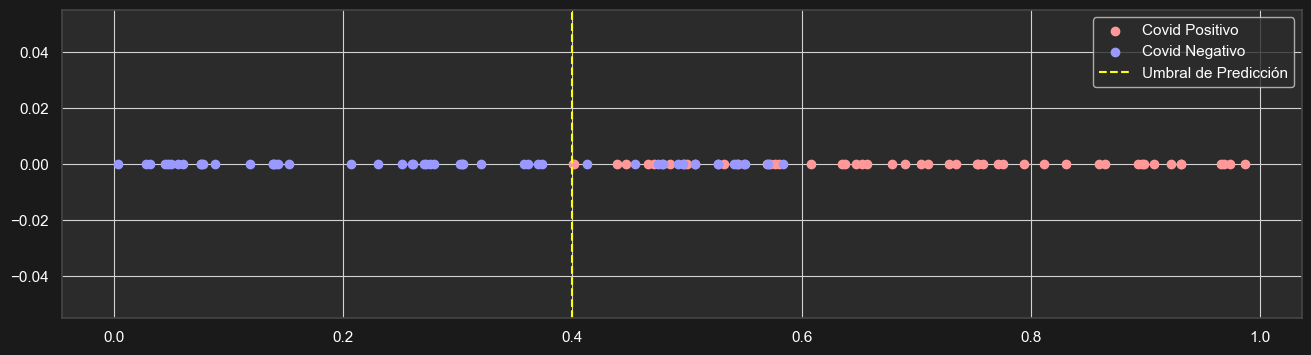

In [24]:
real = df['covid'].values
offset = 0.4
coord = df['coordenada'].values
pred = np.zeros(real.shape)
pred[coord >= offset] = 1

fx, ax = plt.subplots(figsize=(16, 4))
plt.scatter(reds, np.zeros(reds.shape), color='#ff9999', label='Covid Positivo')
plt.scatter(blues, np.zeros(blues.shape), color='#9999ff', label='Covid Negativo')
plt.axvline(x=offset, color='yellow', linestyle='--', label='Umbral de Predicción')
plt.grid(color='lightgray', linewidth=0.8, linestyle='-')
plt.legend()
plt.show()


In [ ]:
from sklearn.metrics import 